Polarisation I indisponible. Le moteur a basculé sur RR.
Polarization I is unavailable.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Chargement du fichier : tests/test_data/0003-066_X.SPLIT.1
Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07     

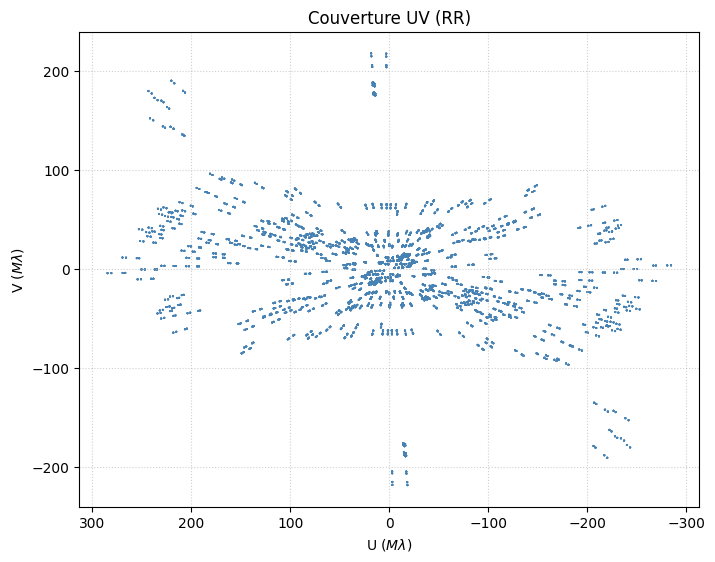

Génération du Radplot...


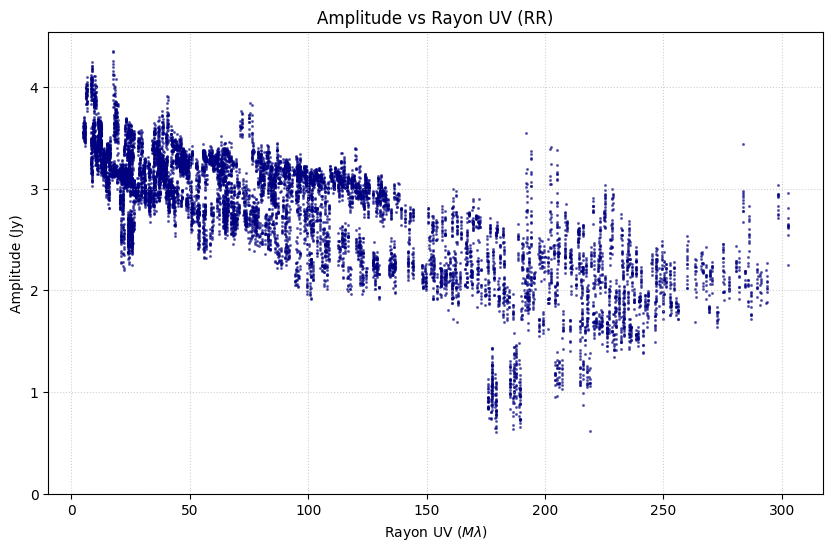

Calcul de la Dirty Map...
Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


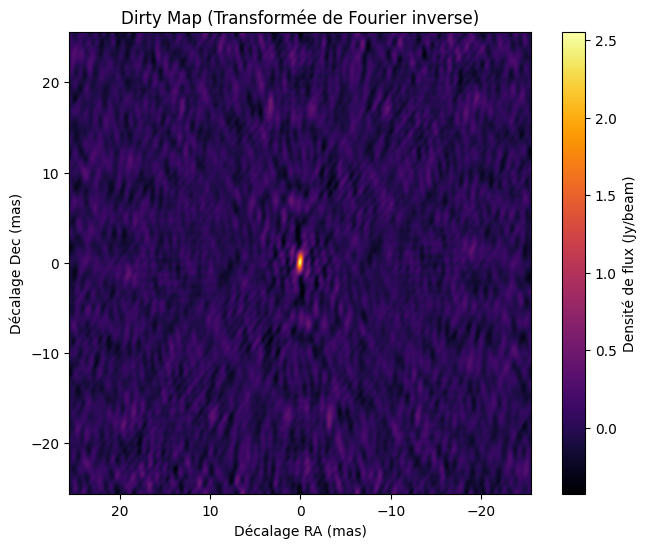

Calcul de la Clean Map (100 itérations CLEAN)...
Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
Component: 050  -  total flux cleaned = 2.40333 Jy
Component: 100  -  total flux cleaned = 2.90978 Jy
Total flux subtracted in 100 components = 2.90978 Jy
Clean residual min=-0.076804 max=0.131075 Jy/beam
Clean residual mean=0.000772 rms=0.017787 Jy/beam
Clean map  min=-0.06816  max=2.5629 Jy/beam


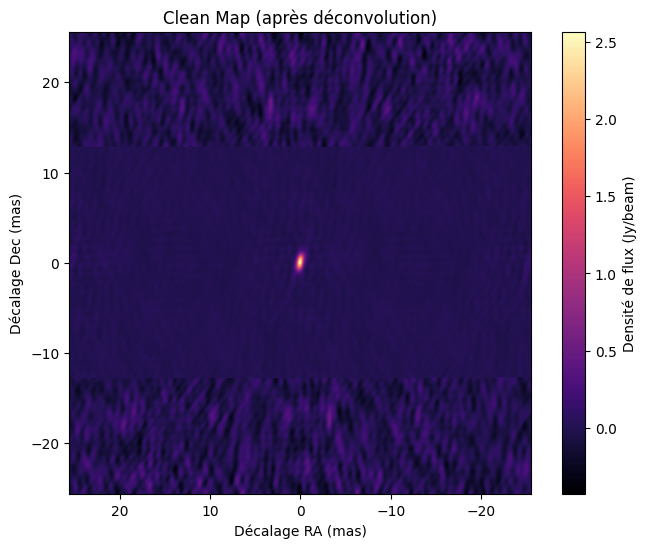

Traitement terminé.


In [4]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from difmap_wrapper import DifmapSession

# Remplacez ceci par le chemin vers votre véritable fichier de visibilités (FITS/UVFITS)
FICHIER_FITS = "tests/test_data/0003-066_X.SPLIT.1"

with DifmapSession() as session:
    
    # 1. Chargement de l'observation
    print(f"Chargement du fichier : {FICHIER_FITS}")
    session.observe(FICHIER_FITS)
    
    # 2. Sélection de la polarisation (ex: Stokes I)
    pol_selectionnee = session.obs.select(pol="I")
    print(f"Polarisation active : {pol_selectionnee}")
    
    # ==========================================
    # GRAPHIQUES DES VISIBILITÉS (Couche Visualizer)
    # ==========================================
    
    print("Génération de la couverture UV...")
    session.vis.uvplot(
        color='steelblue', 
        s=2, 
        alpha=0.6, 
        title=f"Couverture UV ({pol_selectionnee})"
    )
    
    print("Génération du Radplot...")
    session.vis.radplot(
        color='navy', 
        alpha=0.5, 
        s=1.5, 
        title=f"Amplitude vs Rayon UV ({pol_selectionnee})"
    )
    
    # ==========================================
    # IMAGERIE (Couche Imager + Visualizer)
    # ==========================================
    
    # Paramètres d'imagerie
    taille_image = 512        # pixels
    taille_pixel = 0.1        # milli-arcsecondes (mas)
    
    # Plot 3 : Calcul et affichage de la Dirty Map
    print("Calcul de la Dirty Map...")
    dirty_map_pkg = session.imager.make_dirty_map(
        size=taille_image, 
        cellsize=taille_pixel, 
        pol=pol_selectionnee
    )
    
    session.vis.mapplot(
        dirty_map_pkg, 
        cmap='inferno', 
        title="Dirty Map (Transformée de Fourier inverse)"
    )

    
    # Plot 4 : Calcul et affichage de la Clean Map (Déconvolution)
    print("Calcul de la Clean Map (100 itérations CLEAN)...")
    # make_clean_map ajoute l'algorithme CLEAN (déconvolution) et la restauration avec le faisceau
    clean_map_pkg = session.imager.make_clean_map(
        size=taille_image, 
        cellsize=taille_pixel, 
        niter=100,            # Nombre d'itérations CLEAN
        gain=0.05,            # Gain de boucle
        pol=pol_selectionnee
    )
    session.vis.plot_image(
        clean_map_pkg, 
        cmap='magma', 
        title="Clean Map (après déconvolution)"
    )

print("Traitement terminé.")